In [1]:
## imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
## Interactive Matrix Entry


In [4]:
def input_matrix():
    n = int(input("Enter order of matrix: "))

    matrix = []

    print(f"\nEnter {n} x {n} matrix elements row-wise:")

    for i in range(n):
        while True:
            values = input(f"Row {i + 1}: ").split()

            if len(values) != n:
                print(f"Please enter exactly {n} elements.")
                continue

            row = []

            for value in values:
                if "." in value:
                    row.append(float(value))
                else:
                    row.append(int(value))

            matrix.append(row)
            break

    return np.array(matrix)

In [5]:
##  Pretty-Printing a Matrix


In [6]:
def print_matrix(matrix, name="Matrix"):
    print(f"\n{name}:")

    for row in matrix:
        for value in row:
            if value == int(value):
                print(f"{int(value):>10}", end="")
            else:
                print(f"{value:>10.3f}", end="")

        print()

In [7]:
##  Identity Matrix


In [8]:
def display_identity_matrix(A):
    n = A.shape[0]
    I = np.eye(n)

    print_matrix(I, "Identity Matrix I")

    return I

In [9]:
## Symbolic Characteristic Equation


In [10]:
def show_characteristic_equation(A):
    n = A.shape[0]

    print("\n")
    print("CHARACTERISTIC EQUATION")

    for i in range(n):
        row = []

        for j in range(n):
            if i == j:
                row.append(f"({A[i][j]} - λ)")
            else:
                row.append(f"{A[i][j]}")

        print("   ".join(row))

In [11]:
##  Trace and Determinant


In [12]:
def matrix_information(A):
    trace = np.trace(A)
    determinant = np.linalg.det(A)

    print("")

    print(f"Order of matrix  : {A.shape[0]}")
    print(f"Trace of matrix  : {trace:.2f}")
    print(f"Determinant      : {determinant:.2f}")

    return trace, determinant

In [13]:
## Eigenvalues


In [14]:
def calculate_eigenvalues(A):
    
    eigenvalues = np.linalg.eigvals(A)

    print("\nEigenvalues:")

    for i, value in enumerate(eigenvalues, start=1):

        if abs(value.imag) < 1e-10:
            print(f"λ{i} = {value.real:.3f}")
        else:
            print(f"λ{i} = {value:.3f}")

    return eigenvalues

In [15]:
##  Trace/Determinant Checks (sum & product of eigenvalues)


In [16]:
def verify_eigenvalue_properties(A, eigenvalues):

    trace = np.trace(A)
    determinant = np.linalg.det(A)

    sum_eigenvalues = np.sum(eigenvalues)
    product_eigenvalues = np.prod(eigenvalues)

    print("\n")
    print("EIGENVALUE CHECKS")

    print("\nSum of eigenvalues:")
    print(f"Σλ = {sum_eigenvalues:.3f}")

    print(f"Trace(A) = {trace:.3f}")

    if np.allclose(sum_eigenvalues, trace):
        print("Sum of eigenvalues = Trace(A)")

    print("\nProduct of eigenvalues:")
    print(f"Πλ = {product_eigenvalues:.3f}")

    print(f"det(A) = {determinant:.3f}")

    if np.allclose(product_eigenvalues, determinant):
        print("Product of eigenvalues = det(A)")

In [17]:
def plot_scree(sorted_eigs, labels):
    total_variance = np.sum(sorted_eigs)
    explained_ratio = sorted_eigs / total_variance
    cumulative_ratio = np.cumsum(explained_ratio)

    fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
    ax1.bar(labels, explained_ratio * 100, color="#4C72B0", label="Individual variance explained")
    ax1.set_ylabel("Variance explained (%)")
    ax1.set_xlabel("Principal component (sorted by eigenvalue)")

    ax2 = ax1.twinx()
    ax2.plot(labels, cumulative_ratio * 100, color="#C44E52", marker="o", label="Cumulative variance")
    ax2.set_ylabel("Cumulative variance explained (%)")
    ax2.set_ylim(0, 110)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=8)

    ax1.set_title("Scree Plot: Variance Explained by Each Eigenvalue")
    plt.tight_layout()
    plt.savefig("scree_plot.png", dpi=150, bbox_inches="tight")
    plt.show()

    for lbl, ratio, cum in zip(labels, explained_ratio, cumulative_ratio):
        print(f"{lbl}: {ratio*100:5.2f}% individually, {cum*100:5.2f}% cumulative")

In [18]:
## Scree Plot (Variance Explained)


Enter order of matrix: 3

Enter 3 x 3 matrix elements row-wise:
Row 1: 9.067     -10.077      -0.727
Row 2: -10.077     159.125     123.054
Row 3: -0.727     123.054     684.696

Original Matrix A:
     9.067   -10.077    -0.727
   -10.077   159.125   123.054
    -0.727   123.054   684.696

Order of matrix  : 3
Trace of matrix  : 852.89
Determinant      : 782765.73

Identity Matrix I:
         1         0         0
         0         1         0
         0         0         1


CHARACTERISTIC EQUATION
(9.067 - λ)   -10.077   -0.727
-10.077   (159.125 - λ)   123.054
-0.727   123.054   (684.696 - λ)

Eigenvalues:
λ1 = 8.296
λ2 = 132.500
λ3 = 712.092


EIGENVALUE CHECKS

Sum of eigenvalues:
Σλ = 852.888
Trace(A) = 852.888
Sum of eigenvalues = Trace(A)

Product of eigenvalues:
Πλ = 782765.733
det(A) = 782765.733
Product of eigenvalues = det(A)


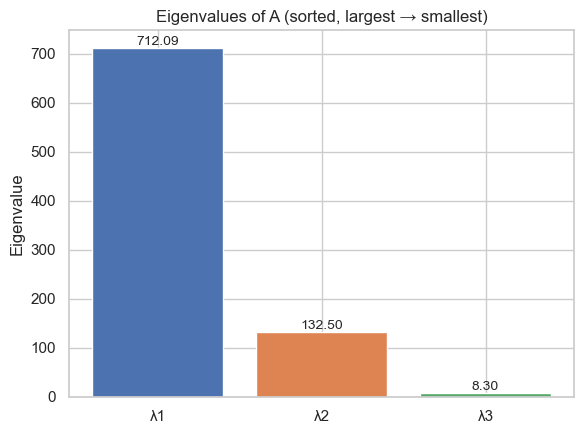

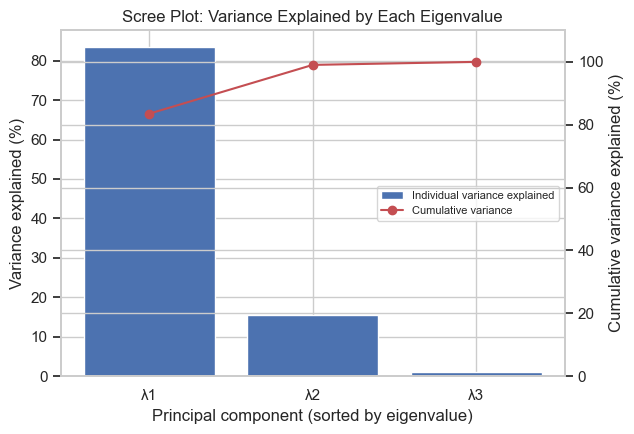

λ1: 83.49% individually, 83.49% cumulative
λ2: 15.54% individually, 99.03% cumulative
λ3:  0.97% individually, 100.00% cumulative


In [19]:
if __name__ == "__main__":
    A = input_matrix()
    print_matrix(A, "Original Matrix A")

    trace, determinant = matrix_information(A)
    I = display_identity_matrix(A)

    show_characteristic_equation(A)
    eigenvalues = calculate_eigenvalues(A)
    verify_eigenvalue_properties(A, eigenvalues)

    order = np.argsort(-eigenvalues.real)
    sorted_eigs = eigenvalues.real[order]
    labels = [f"λ{i+1}" for i in range(len(sorted_eigs))]

    fig, ax = plt.subplots(figsize=(6, 4.5))
    bars = ax.bar(labels, sorted_eigs, color=["#4C72B0", "#DD8452", "#55A868"])
    for bar, val in zip(bars, sorted_eigs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}",
                ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Eigenvalue")
    ax.set_title("Eigenvalues of A (sorted, largest → smallest)")
    plt.tight_layout()
    plt.savefig("eigenvalues_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

    plot_scree(sorted_eigs, labels)